In [19]:
import requests
import pandas as pd
import time

BASE_URL = "https://fantasy.premierleague.com/api"

bootstrap = requests.get(f"{BASE_URL}/bootstrap-static/").json()

players = pd.DataFrame(bootstrap["elements"])
teams = pd.DataFrame(bootstrap["teams"])

team_map = teams.set_index("id")["name"]
players["team_name"] = players["team"].map(team_map)

players[["id", "web_name", "team_name", "element_type"]].head()

,id,web_name,team_name,element_type
0,1,Raya,Arsenal,1
1,2,Arrizabalaga,Arsenal,1
2,3,Hein,Arsenal,1
3,4,Setford,Arsenal,1
4,5,Gabriel,Arsenal,2


In [23]:
def get_player_last5(player_id):
    url = f"{BASE_URL}/element-summary/{player_id}/"
    data = requests.get(url).json()
    
    history = pd.DataFrame(data["history"])
    
    if history.empty:
        return None
    
    last5 = history.tail(5)
    
    return {
        "player_id": player_id,
        "last5_minutes": last5["minutes"].sum(),
        "last5_goals": last5["goals_scored"].sum(),
        "last5_assists": last5["assists"].sum(),
        "last5_ga": last5["goals_scored"].sum() + last5["assists"].sum(),
        "last5_xg": pd.to_numeric(last5["expected_goals"], errors="coerce").sum(),
        "last5_xa": pd.to_numeric(last5["expected_assists"], errors="coerce").sum(),
    }

In [24]:
players_clean = players[[
    "id",
    "web_name",
    "first_name",
    "second_name",
    "team_name",
    "element_type",
    "minutes",
    "goals_scored",
    "assists",
    "expected_goals",
    "expected_assists",
    "form",
    "now_cost"
]].copy()

players_clean["full_name"] = (
    players_clean["first_name"] + " " + players_clean["second_name"]
)

players_clean = players_clean[
    (players_clean["element_type"].isin([3, 4])) &
    (players_clean["minutes"] > 0)
].copy()

players_clean.head()

,id,web_name,first_name,second_name,team_name,element_type,minutes,goals_scored,assists,expected_goals,expected_assists,form,now_cost,full_name
14,16,Saka,Bukayo,Saka,Arsenal,3,2128,7,9,7.37,6.87,3.5,100,Bukayo Saka
15,17,Ødegaard,Martin,Ødegaard,Arsenal,3,1273,1,7,1.04,3.56,2.2,78,Martin Ødegaard
16,18,Madueke,Noni,Madueke,Arsenal,3,1122,2,1,1.06,2.56,1.5,68,Noni Madueke
17,19,Martinelli,Gabriel,Martinelli Silva,Arsenal,3,974,1,4,3.99,1.03,0.2,68,Gabriel Martinelli Silva
18,20,Trossard,Leandro,Trossard,Arsenal,3,1907,6,6,5.52,3.48,4.0,65,Leandro Trossard


In [25]:
attackers = players_clean[
    players_clean["minutes"] >= 300
].copy()

attackers[["id", "full_name", "web_name", "team_name", "minutes"]].head()

,id,full_name,web_name,team_name,minutes
14,16,Bukayo Saka,Saka,Arsenal,2128
15,17,Martin Ødegaard,Ødegaard,Arsenal,1273
16,18,Noni Madueke,Madueke,Arsenal,1122
17,19,Gabriel Martinelli Silva,Martinelli,Arsenal,974
18,20,Leandro Trossard,Trossard,Arsenal,1907


In [27]:
last5_data = []

for player_id in attackers["id"]:
    result = get_player_last5(player_id)

    if result:
        last5_data.append(result)
        
        print(f"Processed player ID {player_id}")

    time.sleep(0.2)

last5_df = pd.DataFrame(last5_data)
last5_df.head()

Processed player ID 16
Processed player ID 17
Processed player ID 18
Processed player ID 19
Processed player ID 20
Processed player ID 21
Processed player ID 22
Processed player ID 26
Processed player ID 30
Processed player ID 31
Processed player ID 266
Processed player ID 666
Processed player ID 47
Processed player ID 48
Processed player ID 49
Processed player ID 50
Processed player ID 53
Processed player ID 54
Processed player ID 55
Processed player ID 58
Processed player ID 59
Processed player ID 64
Processed player ID 456
Processed player ID 699
Processed player ID 200
Processed player ID 202
Processed player ID 205
Processed player ID 206
Processed player ID 207
Processed player ID 209
Processed player ID 210
Processed player ID 215
Processed player ID 217
Processed player ID 614
Processed player ID 676
Processed player ID 680
Processed player ID 722
Processed player ID 81
Processed player ID 84
Processed player ID 85
Processed player ID 86
Processed player ID 87
Processed player 

,player_id,last5_minutes,last5_goals,last5_assists,last5_ga,last5_xg,last5_xa
0,16,133,1,1,2,0.38,1.12
1,17,203,0,1,1,0.03,0.65
2,18,233,0,0,0,0.03,0.50
3,19,135,0,0,0,0.46,0.03
4,20,232,1,1,2,0.56,0.78


In [29]:
final = attackers.merge(
    last5_df,
    left_on="id",
    right_on="player_id",
    how="left"
)

final.columns

Index(['id', 'web_name', 'first_name', 'second_name', 'team_name',
       'element_type', 'minutes', 'goals_scored', 'assists', 'expected_goals',
       'expected_assists', 'form', 'now_cost', 'full_name', 'player_id',
       'last5_minutes', 'last5_goals', 'last5_assists', 'last5_ga', 'last5_xg',
       'last5_xa'],
      dtype='object')

In [33]:
players_clean = final[[
    'team_name',
    'full_name',
    'last5_minutes', 'last5_goals', 'last5_assists', 'last5_ga', 'last5_xg',
    'last5_xa'
]].copy()

In [35]:
players_clean["expected_goal_contribution"] = players_clean["last5_xg"] + players_clean["last5_xa"]

players_clean.head()

,team_name,full_name,last5_minutes,last5_goals,last5_assists,last5_ga,last5_xg,last5_xa,expected_goal_contribution
0,Arsenal,Bukayo Saka,133,1,1,2,0.38,1.12,1.50
1,Arsenal,Martin Ødegaard,203,0,1,1,0.03,0.65,0.68
2,Arsenal,Noni Madueke,233,0,0,0,0.03,0.50,0.53
3,Arsenal,Gabriel Martinelli Silva,135,0,0,0,0.46,0.03,0.49
4,Arsenal,Leandro Trossard,232,1,1,2,0.56,0.78,1.34


In [37]:
players_clean.sort_values("expected_goal_contribution", ascending=False)

,team_name,full_name,last5_minutes,last5_goals,last5_assists,last5_ga,last5_xg,last5_xa,expected_goal_contribution
150,Man City,Erling Haaland,360,4,1,5,3.63,0.21,3.84
128,Leeds,Dominic Calvert-Lewin,450,3,0,3,3.67,0.05,3.72
172,Newcastle,William Osula,375,3,0,3,2.68,0.42,3.10
55,Brentford,Igor Thiago Nascimento Rodrigues,450,3,0,3,2.90,0.12,3.02
11,Arsenal,Viktor Gyökeres,305,3,1,4,2.87,0.07,2.94
...,...,...,...,...,...,...,...,...,...
42,Bournemouth,Lewis Cook,0,0,0,0,0.00,0.00,0.00
194,Sunderland,Eliezer Mayenda Dossou,1,0,0,0,0.00,0.00,0.00
103,Everton,Jack Grealish,0,0,0,0,0.00,0.00,0.00
198,Spurs,Mohammed Kudus,0,0,0,0,0.00,0.00,0.00


In [38]:
players_clean

,team_name,full_name,last5_minutes,last5_goals,last5_assists,last5_ga,last5_xg,last5_xa,expected_goal_contribution
0,Arsenal,Bukayo Saka,133,1,1,2,0.38,1.12,1.50
1,Arsenal,Martin Ødegaard,203,0,1,1,0.03,0.65,0.68
2,Arsenal,Noni Madueke,233,0,0,0,0.03,0.50,0.53
3,Arsenal,Gabriel Martinelli Silva,135,0,0,0,0.46,0.03,0.49
4,Arsenal,Leandro Trossard,232,1,1,2,0.56,0.78,1.34
...,...,...,...,...,...,...,...,...,...
229,Wolves,Jhon Arias,0,0,0,0,0.00,0.00,0.00
230,Wolves,Tolu Arokodare,129,0,0,0,0.65,0.03,0.68
231,Wolves,Mateus Mané,327,0,0,0,0.36,0.93,1.29
232,Wolves,Angel Gomes,110,0,0,0,0.14,0.11,0.25


In [39]:
graph_df = players_clean.copy()

graph_df["actual_gc"] = graph_df["last5_ga"]

graph_df["expected_gc"] = (
    graph_df["last5_xg"] +
    graph_df["last5_xa"]
)

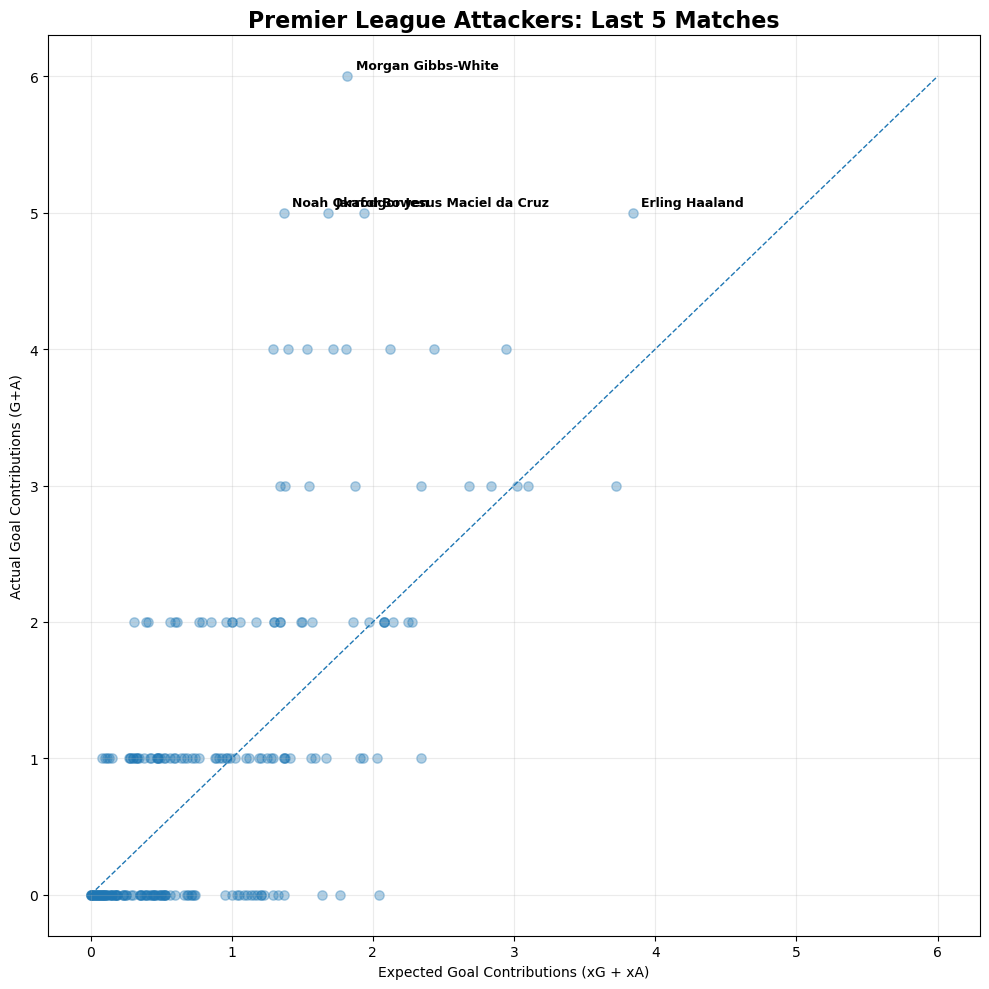

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

graph_df = players_clean.copy()

graph_df = graph_df[graph_df["last5_minutes"] > 1].copy()

graph_df["actual_gc"] = graph_df["last5_ga"]
graph_df["expected_gc"] = graph_df["last5_xg"] + graph_df["last5_xa"]

fig, ax = plt.subplots(figsize=(10, 10))

# ALL players
ax.scatter(
    graph_df["expected_gc"],
    graph_df["actual_gc"],
    s=45,
    alpha=0.35
)

# ONLY label players with 5+ G+A
label_df = graph_df[graph_df["actual_gc"] >= 5]

for _, row in label_df.iterrows():
    ax.annotate(
        row["full_name"],
        (row["expected_gc"], row["actual_gc"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9,
        weight="bold"
    )

# x=y line
max_val = max(graph_df["expected_gc"].max(), graph_df["actual_gc"].max())

ax.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Premier League Attackers: Last 5 Matches",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Expected Goal Contributions (xG + xA)")
ax.set_ylabel("Actual Goal Contributions (G+A)")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

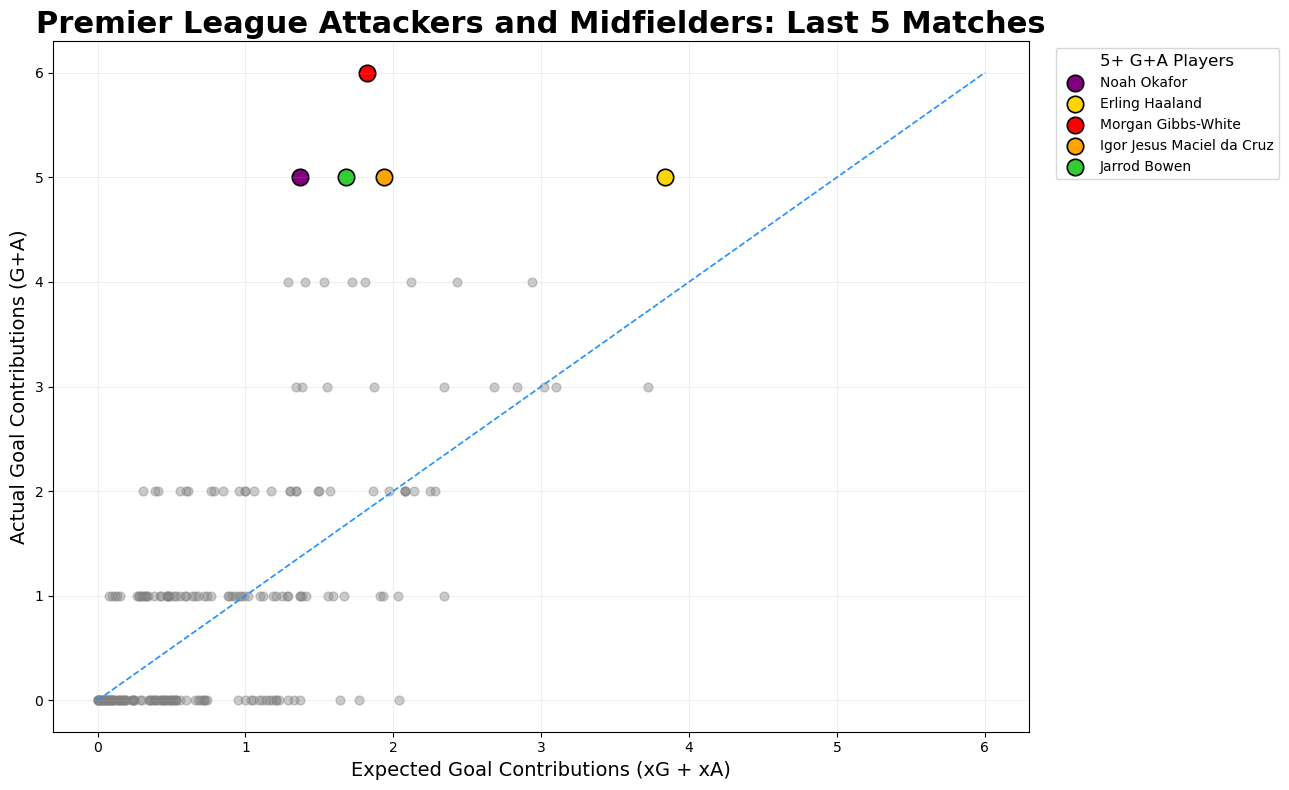

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

graph_df = players_clean.copy()

graph_df = graph_df[graph_df["last5_minutes"] > 1].copy()

graph_df["actual_gc"] = graph_df["last5_ga"]
graph_df["expected_gc"] = graph_df["last5_xg"] + graph_df["last5_xa"]

highlight_df = graph_df[graph_df["actual_gc"] >= 5].copy()
other_df = graph_df[graph_df["actual_gc"] < 5].copy()

# custom colors for highlighted players
player_colors = {
    "Morgan Gibbs-White": "red",
    "Erling Haaland": "gold",
    "Jarrod Bowen": "limegreen",
    "Noah Okafor": "purple",
    "Igor Jesus Maciel da Cruz": "orange"
}

fig, ax = plt.subplots(figsize=(13, 8))

# OTHER PLAYERS
ax.scatter(
    other_df["expected_gc"],
    other_df["actual_gc"],
    s=40,
    alpha=0.4,
    color="gray"
)

# HIGHLIGHTED PLAYERS
for _, row in highlight_df.iterrows():

    player = row["full_name"]

    color = player_colors.get(player, "red")

    ax.scatter(
        row["expected_gc"],
        row["actual_gc"],
        s=140,
        color=color,
        edgecolor="black",
        linewidth=1.2,
        label=player
    )

# x = y line
max_val = max(
    graph_df["expected_gc"].max(),
    graph_df["actual_gc"].max()
)

ax.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    linewidth=1.2,
    color="dodgerblue"
)

# CLEAN LEGEND
handles, labels = ax.get_legend_handles_labels()

unique = dict(zip(labels, handles))

legend = ax.legend(
    unique.values(),
    unique.keys(),
    title="5+ G+A Players",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=10,
    title_fontsize=12,
    frameon=True
)

# TITLES
ax.set_title(
    "Premier League Attackers and Midfielders: Last 5 Matches",
    fontsize=22,
    weight="bold"
)

ax.set_xlabel(
    "Expected Goal Contributions (xG + xA)",
    fontsize=14
)

ax.set_ylabel(
    "Actual Goal Contributions (G+A)",
    fontsize=14
)

ax.grid(alpha=0.2)

plt.tight_layout()

plt.show()